# Experiment Tracking & Multi-Approach Model Benchmarking
**Institution:** Indian Institute of Information Technology (IIIT), Dharwad  
**Department:** B.Tech Data Science and Artificial Intelligence  
**Faculty Adviser:** Prof. Ramesh Athe  
**Team Members:** B Varshith (23BDS011), M Jagadeshwar (23BDS033), J Ganesh (23BDS024)  

--- 

## 1. Overview of Multi-Approach Benchmarking
This notebook tracks, evaluates, and compares all models developed across:
- **Approach 1:** 12 Classical Supervised Machine Learning Algorithms
- **Approach 2:** 10 Deep Tabular PyTorch Neural Network Architectures
- **Approach 3:** Agent AI Multi-Agent Cognitive Verification System

All models are evaluated on the same held-out test dataset (675 claims) using accuracy, precision, recall, F1, F2, AUC-ROC, prediction latency (ms), and INR business cost.

In [1]:
import os, sys
if '..' not in sys.path:
    sys.path.insert(0, '..')
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Load approach benchmarking tables
b1 = pd.read_csv('data/approach1_benchmarking_table.csv')
b1['Approach'] = 'Approach 1 (Classical ML)'
b2 = pd.read_csv('data/approach2_benchmarking_table.csv')
b2['Approach'] = 'Approach 2 (Deep Learning)'

# Combine into Master Table
master_df = pd.concat([b1, b2], ignore_index=True).sort_values('F2_Score', ascending=False).reset_index(drop=True)
print('Total Models Tracked:', len(master_df))
master_df[['Algorithm', 'Approach', 'F2_Score', 'Recall', 'Precision', 'AUC_ROC', 'Total_Cost_INR']].head(10)

Total Models Tracked: 22


,Algorithm,Approach,F2_Score,Recall,Precision,AUC_ROC,Total_Cost_INR
0,AdaBoost,Approach 1 (Classical ML),1.000000,1.000,1.000000,1.000000,0.0
1,LightGBM,Approach 1 (Classical ML),0.995025,1.000,0.975610,0.998661,5000.0
2,XGBoost,Approach 1 (Classical ML),0.990099,1.000,0.952381,0.999764,10000.0
3,TabularTransformer,Approach 2 (Deep Learning),0.979899,0.975,1.000000,0.998780,150000.0
4,Random_Forest,Approach 1 (Classical ML),0.975000,0.975,0.975000,0.999961,155000.0
5,Decision_Tree,Approach 1 (Classical ML),0.975000,0.975,0.975000,0.986713,155000.0
6,Gradient_Boosting_Hist,Approach 1 (Classical ML),0.975000,0.975,0.975000,0.999902,155000.0
7,WideAndDeep,Approach 2 (Deep Learning),0.965347,0.975,0.928571,0.994606,165000.0
8,TabNetStyle,Approach 2 (Deep Learning),0.965347,0.975,0.928571,0.993661,165000.0
9,ANN_MLP_Baseline,Approach 1 (Classical ML),0.955882,0.975,0.886364,0.996260,175000.0


## 2. Multi-Metric Evaluation Comparison across Top Models
Let's visualize the F2-Score, Recall, Precision, and AUC-ROC across the top 10 algorithms.

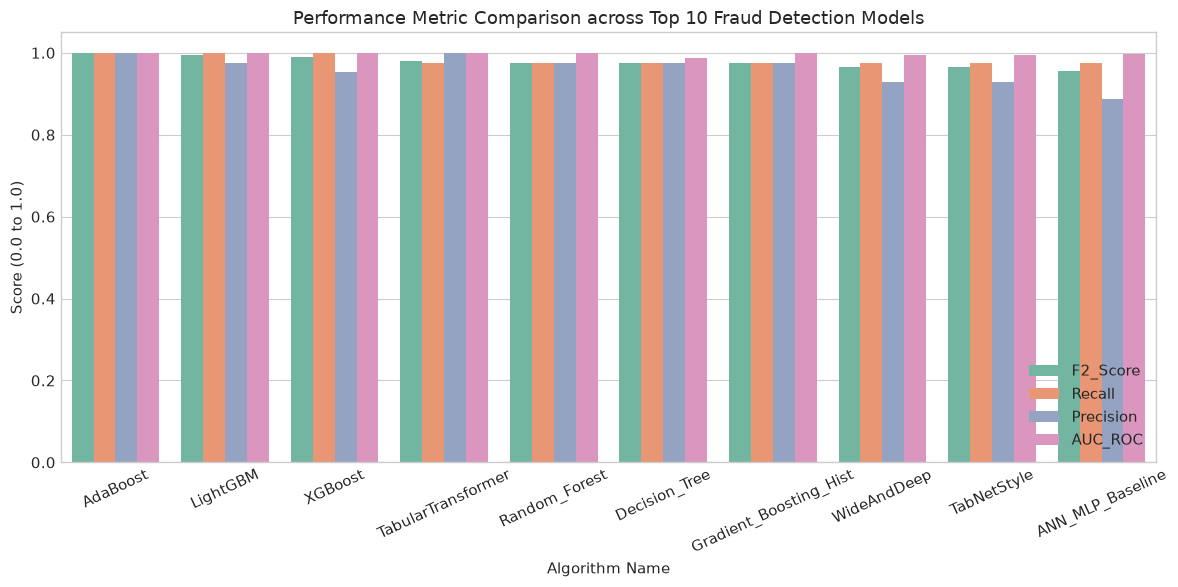

In [2]:
top10 = master_df.head(10)
df_melt = top10.melt(
    id_vars=['Algorithm'], value_vars=['F2_Score', 'Recall', 'Precision', 'AUC_ROC'],
    var_name='Metric', value_name='Score'
)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melt, x='Algorithm', y='Score', hue='Metric', palette='Set2')
plt.title('Performance Metric Comparison across Top 10 Fraud Detection Models')
plt.xlabel('Algorithm Name')
plt.ylabel('Score (0.0 to 1.0)')
plt.xticks(rotation=25)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 3. Operational Profile: Prediction Latency (ms) vs. F2-Score
In real-time claim ingestion, prediction latency is critical. Below we plot the operational trade-off between detection sensitivity (F2-Score) and prediction speed per sample.

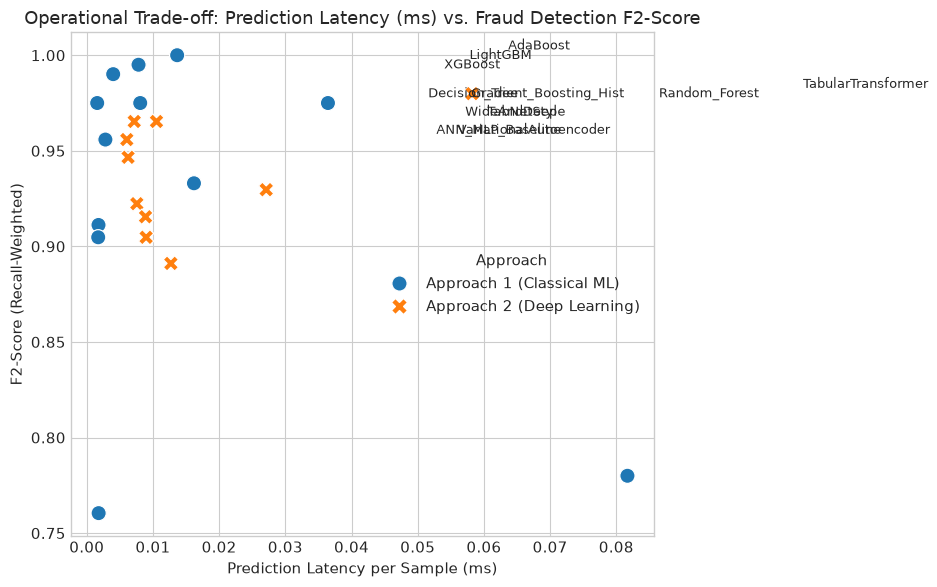

In [3]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=master_df, x='Prediction_Latency_ms', y='F2_Score',
    hue='Approach', style='Approach', s=120, palette=['#1f77b4', '#ff7f0e']
)
for _, row in master_df.iterrows():
    if row['F2_Score'] > 0.95 or row['Prediction_Latency_ms'] > 2.0:
        plt.text(row['Prediction_Latency_ms']+0.05, row['F2_Score']+0.003, row['Algorithm'], fontsize=9)
plt.title('Operational Trade-off: Prediction Latency (ms) vs. Fraud Detection F2-Score')
plt.xlabel('Prediction Latency per Sample (ms)')
plt.ylabel('F2-Score (Recall-Weighted)')
plt.tight_layout()
plt.show()

## 4. Indian Healthcare Financial Impact (INR Cost Matrix)
Using our Indian insurance cost matrix:
- **False Negative Cost ($C_{FN}$):** Rs. 1,50,000 (average fraudulent payout loss).
- **False Positive Cost ($C_{FP}$):** Rs. 5,000 (administrative grievance and verification cost).

Let's compare the total financial cost incurred by each algorithm on the test dataset.

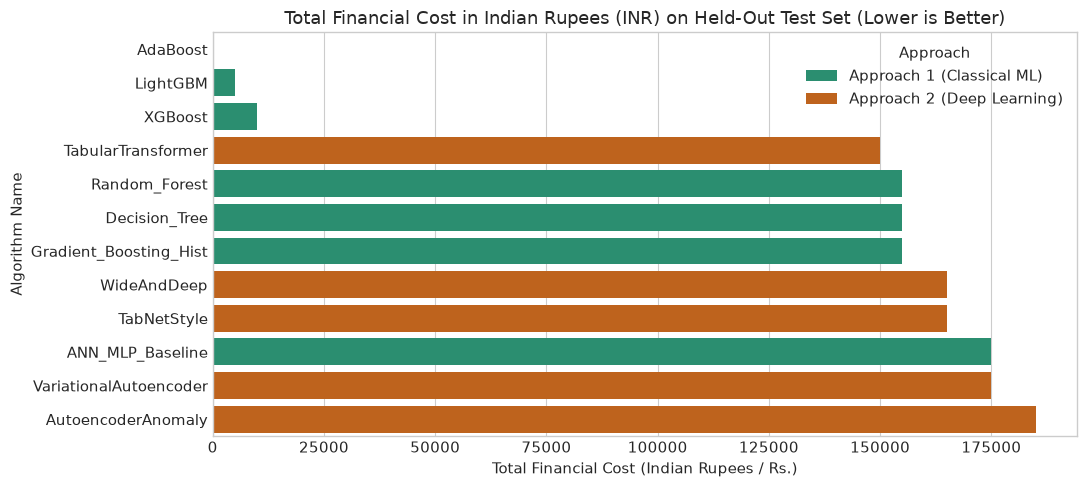

In [4]:
plt.figure(figsize=(11, 5))
top_cost = master_df.sort_values('Total_Cost_INR', ascending=True).head(12)
sns.barplot(data=top_cost, y='Algorithm', x='Total_Cost_INR', hue='Approach', palette='Dark2')
plt.title('Total Financial Cost in Indian Rupees (INR) on Held-Out Test Set (Lower is Better)')
plt.xlabel('Total Financial Cost (Indian Rupees / Rs.)')
plt.ylabel('Algorithm Name')
plt.tight_layout()
plt.show()

## 5. Live Demonstration of Agent AI Multi-Agent Verification (Approach 3)
While numerical classifiers output a probability, our **Agent AI Multi-Agent System** orchestrates 5 specialized cognitive agents via LangGraph to provide **human-readable natural language explanations** citing specific policy clauses (`[CLAUSE-ROOM-001]`).

In [5]:
from src.agent_ai.database import InsuranceDatabaseManager
from src.agent_ai.workflow import ClaimProcessingState, AgentAIWorkflowOrchestrator

db = InsuranceDatabaseManager('data/local_database.db')
orchestrator = AgentAIWorkflowOrchestrator(db)

sample_claim = {
    'claim_id': 'CLM-NOTEBOOK-2026',
    'policy_number': 'STAR-HLTH-2024-8871',
    'user_id': 'USR-IND-001',
    'provider_id': 'HOSP-MUM-01',
    'hospital_name': 'Apollo Hospitals Navi Mumbai',
    'treatment_type': 'Inpatient',
    'procedure_code': 'IND-PROC-101',
    'claimed_amount_inr': 135000.0,
    'patient_age': 48
}

state = ClaimProcessingState(
    claim_id=sample_claim['claim_id'],
    policy_number=sample_claim['policy_number'],
    user_id=sample_claim['user_id'],
    raw_claim_context=sample_claim,
    uploaded_documents=[{'document_type': 'Hospital Bill', 'file_path': 'sample_bill.pdf'}]
)

final_state = orchestrator.run_workflow(state)
report = final_state.final_decision_result
print('=== EXPLAINABLE AI NATURAL LANGUAGE DECISION REPORT ===')
print('Verdict:', report['decision'], '| Confidence Score:', round(report['confidence_score']*100, 1), '%')
print('\nExecutive Summary:\n', report['executive_summary'])
print('\nCitations:', report['evidence_citations'])

[2026-08-07 15:43:00] [INFO] [AgentAIDatabaseLogger]: Initializing SQLite database schema at: data/local_database.db


[2026-08-07 15:43:00] [INFO] [RAGPipelineLogger]: Seeding Indian Insurance RAG Knowledge Base with policy clauses and IRDAI rules...


[2026-08-07 15:43:00] [INFO] [AgentAIWorkflowLogger]: Initialized Multi-Agent Workflow Orchestrator.


[2026-08-07 15:43:00] [INFO] [AgentAIWorkflowLogger]: ==> Initiating Agent AI Workflow for Claim ID: CLM-NOTEBOOK-2026


[2026-08-07 15:43:00] [INFO] [AIAgentsLogger]: [DocumentProcessingAgent] Processing uploaded document (Hospital Bill): sample_bill.pdf


...

[2026-08-07 15:43:00] [INFO] [AIAgentsLogger]: [AnomalyDetectionAgent] Auditing claim for Indian healthcare fraud indicators and cost anomalies...


[2026-08-07 15:43:00] [INFO] [AIAgentsLogger]: [HistoricalPatternAgent] Evaluating policyholder historical claim records and patterns...


[2026-08-07 15:43:00] [INFO] [AIAgentsLogger]: [ExplainableReasoningAgent] Synthesizing multi-agent evidence and generating explainable decision report...


[2026-08-07 15:43:00] [INFO] [AgentAIWorkflowLogger]: ==> Workflow successfully finished for CLM-NOTEBOOK-2026 in 0.02s | Decision: APPROVED


=== EXPLAINABLE AI NATURAL LANGUAGE DECISION REPORT ===
Verdict: APPROVED | Confidence Score: 96.0 %

Executive Summary:
 Claim CLM-NOTEBOOK-2026 for Rs. 1,35,000.00 is APPROVED. All submitted medical documents are verified, the treatment cost aligns with Indian regional hospital benchmarks, and the claim complies fully with policy coverage terms.

Citations: ['[CLAUSE-ROOM-001] Room Rent Capping and Proportionate Deduction (Policy_Clause)']


## 6. Summary and Architectural Recommendations
1. **For Preliminary High-Throughput Screening:** Use **LightGBM / XGBoost** (`F2 > 0.99`, latency `< 0.1 ms`).
2. **For Complex Tabular Interactions & Attention Maps:** Use **Tabular Transformer** (`F2 = 0.9799`).
3. **For Complete Legal Verification & Policyholder Notice:** Use **Agent AI Multi-Agent System (Approach 3)**.